In [219]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

import optuna
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

seed = 42

In [23]:
train = pd.read_csv('train.csv',header=None)
test = pd.read_csv('test.csv',header=None)

In [24]:
X_train, X_test, y_train, y_test = train.iloc[:,:-1] , test.iloc[:,:-1], train.iloc[:,-1], test.iloc[:,-1]

In [25]:
print('X_train shape ',X_train.shape)
print('X_test shape ',X_test.shape)
print('y_train shape ',y_train.shape)
print('y_test shape ',y_test.shape)

X_train shape  (3823, 64)
X_test shape  (1797, 64)
y_train shape  (3823,)
y_test shape  (1797,)


In [108]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,0,6,14,7,1,0,0
1,0,0,10,16,6,0,0,0,0,7,...,3,0,0,0,10,16,15,3,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,0,9,14,0,0,0,0
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,0,1,15,2,0,0
4,0,0,5,14,4,0,0,0,0,0,...,12,0,0,0,4,12,14,7,0,0


In [88]:
label_count = y_train.value_counts(normalize=True)

<Axes: xlabel='64'>

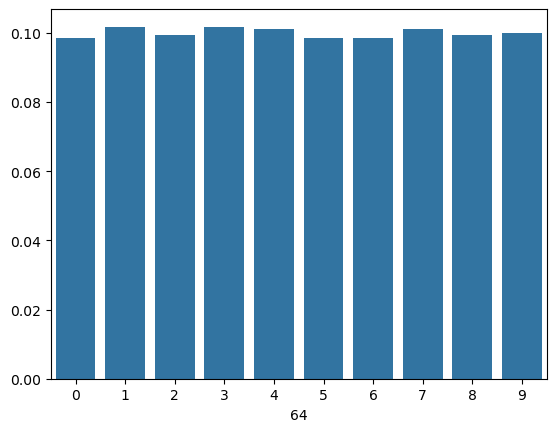

In [89]:
sns.barplot(x=label_count.index,y=label_count.values)

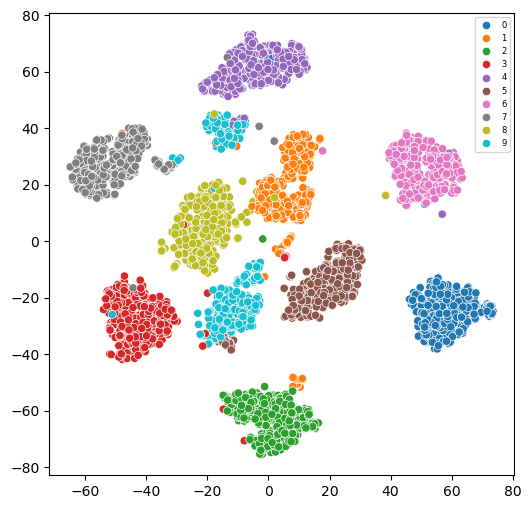

In [107]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    early_exaggeration=12,
    method='barnes_hut',
    angle=0.4
)
reduced = tsne.fit_transform(X_train)
plt.figure(figsize=(6,6))
sns.scatterplot(x=reduced[:,0],y=reduced[:,1],hue=y_train,palette=sns.color_palette())
plt.legend(fontsize=6)

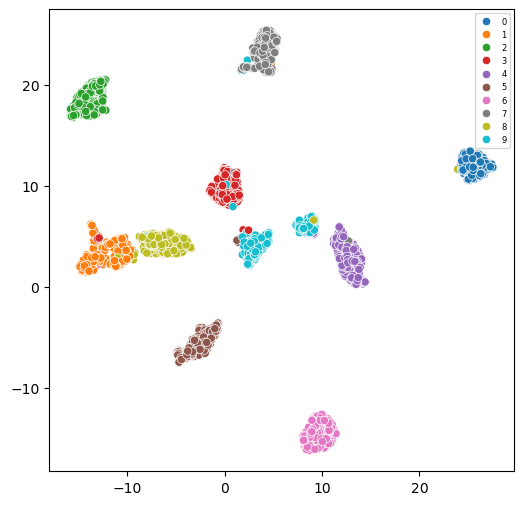

In [110]:
umap_obj = umap.UMAP(n_neighbors=25,
                     n_components=2,
                     min_dist=0.1,
                     spread=2
                    )
reduced = umap_obj.fit_transform(X_train)
plt.figure(figsize=(6,6))
sns.scatterplot(x=reduced[:,0],y=reduced[:,1],hue=y_train,palette=sns.color_palette())
plt.legend(fontsize=6)

In [123]:
def model_trainer(model,model_params,X,y,n_trials=30):
    def objective(trial):
        params = model_params(trial)
        model.set_params(**params)
        score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
        return score
        
    study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective,n_trials=n_trials)
    
    model.set_params(**study.best_trial.params)
    model.fit(X,y)

    return study, model

In [129]:
def visualize(study,model,X,y):
    plot_optimization_history(study).show()
    plot_parallel_coordinate(study).show()
    plot_param_importances(study).show()



In [124]:
def rf_params(trial):

    return {
        'n_estimators':trial.suggest_int('n_estimators',50,500),
        'criterion': trial.suggest_categorical('criterion',["gini", "entropy", "log_loss"]),
        'max_depth': trial.suggest_int('max_depth',3,15),
        'min_samples_split':trial.suggest_int('min_samples_split',2,20),
        'min_samples_leaf':trial.suggest_int('min_samples_leaf',1,20),
        'max_features':trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'max_samples': trial.suggest_float('max_samples', 0.1, 1.0) if trial.params['bootstrap'] else None,
        'min_impurity_decrease':trial.suggest_float('min_impurity_decrease',0.0,0.2),
        'ccp_alpha':trial.suggest_float('ccp_alpha',0,0.1)
        }

rf = RandomForestClassifier()

rf_study, rf = model_trainer(rf,rf_params,X_train,y_train)

[I 2025-04-17 03:03:20,268] A new study created in memory with name: no-name-10325a73-ffa4-440c-b57f-49f59d7e8671
[I 2025-04-17 03:03:21,644] Trial 0 finished with value: 0.10149094891010506 and parameters: {'n_estimators': 218, 'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'min_impurity_decrease': 0.16648852816008436, 'ccp_alpha': 0.021233911067827616}. Best is trial 0 with value: 0.10149094891010506.
[I 2025-04-17 03:03:33,300] Trial 1 finished with value: 0.7342480238168566 and parameters: {'n_estimators': 132, 'criterion': 'log_loss', 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 13, 'max_features': None, 'bootstrap': False, 'min_impurity_decrease': 0.03993475643167195, 'ccp_alpha': 0.05142344384136116}. Best is trial 1 with value: 0.7342480238168566.
[I 2025-04-17 03:03:35,721] Trial 2 finished with value: 0.8773243677924922 and parameters: {'n_estimators': 317, 'criterion': 'entropy', 

In [128]:
print('Best Trial Value: ',rf_study.best_trial.value)
print('Train score: ',accuracy_score(y_train,rf.predict(X_train)))
print('Test score: ',accuracy_score(y_test,rf.predict(X_test)))

Best Trial Value:  0.9461198371146015
Train score:  0.9628563955009155
Test score:  0.9326655537006121


In [126]:
print(classification_report(y_test,rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       178
           1       0.91      0.88      0.89       182
           2       0.94      0.95      0.95       177
           3       0.89      0.91      0.90       183
           4       0.97      0.98      0.97       181
           5       0.95      0.95      0.95       182
           6       0.99      0.97      0.98       181
           7       0.93      0.92      0.93       179
           8       0.92      0.89      0.91       174
           9       0.86      0.88      0.87       180

    accuracy                           0.93      1797
   macro avg       0.93      0.93      0.93      1797
weighted avg       0.93      0.93      0.93      1797



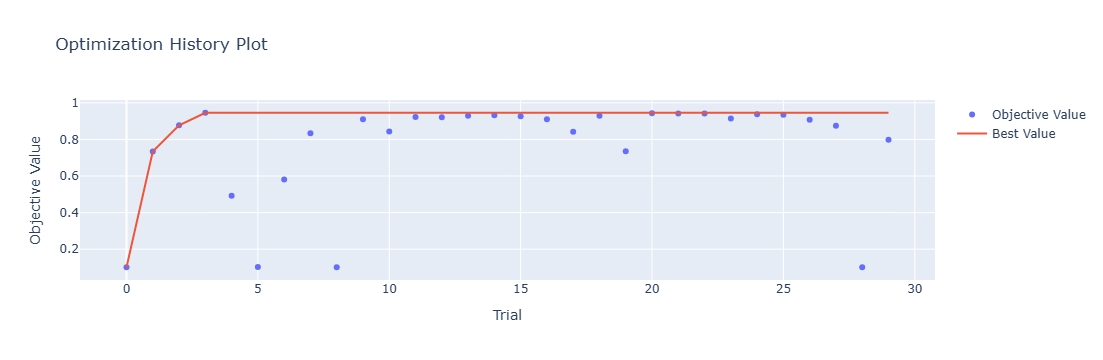

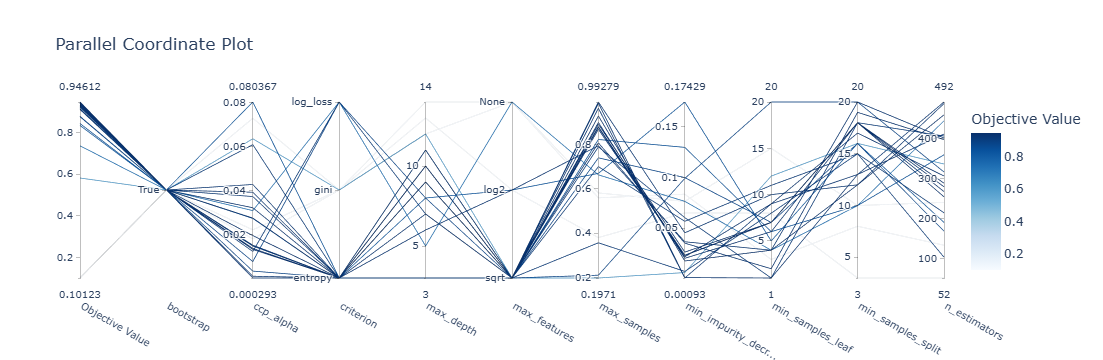

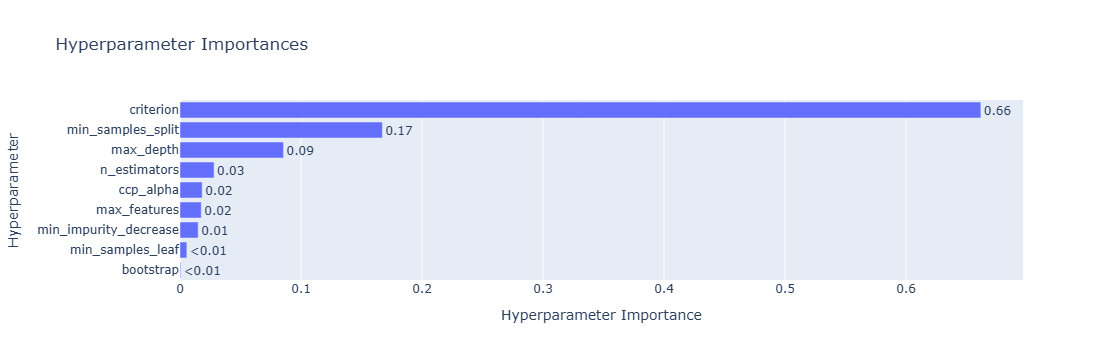

In [134]:
visualize(rf_study)

In [137]:
def umap_rf_params(trial):

    return {
        'umap__n_neighbors':trial.suggest_int('umap__n_neighbors',5,100),
        'umap__n_components':trial.suggest_int('umap__n_components',2,64),
        'umap__min_dist':trial.suggest_float('umap__min_dist',0.1,0.5),
        'umap__metric':trial.suggest_categorical('umap__metric',['euclidean', 'manhattan', 'correlation']),
        'rf__n_estimators':trial.suggest_int('rf__n_estimators',50,500),
        'rf__criterion': trial.suggest_categorical('rf__criterion',["gini", "entropy", "log_loss"]),
        'rf__max_depth': trial.suggest_int('rf__max_depth',3,15),
        'rf__min_samples_split':trial.suggest_int('rf__min_samples_split',2,20),
        'rf__min_samples_leaf':trial.suggest_int('rf__min_samples_leaf',1,20),
        'rf__max_features':trial.suggest_categorical('rf__max_features', ['sqrt', 'log2', None]),
        'rf__bootstrap': trial.suggest_categorical('rf__bootstrap', [True, False]),
        'rf__max_samples': trial.suggest_float('rf__max_samples', 0.1, 1.0) if trial.params['rf__bootstrap'] else None,
        'rf__min_impurity_decrease':trial.suggest_float('rf__min_impurity_decrease',0.0,0.2),
        'rf__ccp_alpha':trial.suggest_float('rf__ccp_alpha',0,0.1)
        }

umap_rf = Pipeline([
    ('umap',umap.UMAP()),
    ('rf',RandomForestClassifier())
])

umap_rf_study, umap_rf = model_trainer(umap_rf,umap_rf_params,X_train,y_train)

[I 2025-04-17 03:26:55,500] A new study created in memory with name: no-name-7719106e-9bf2-4f0f-be87-aabf804d2826
[I 2025-04-17 03:27:56,760] Trial 0 finished with value: 0.8736857954351025 and parameters: {'umap__n_neighbors': 40, 'umap__n_components': 61, 'umap__min_dist': 0.39279757672456206, 'umap__metric': 'euclidean', 'rf__n_estimators': 76, 'rf__criterion': 'gini', 'rf__max_depth': 3, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 17, 'rf__max_features': 'sqrt', 'rf__bootstrap': False, 'rf__min_impurity_decrease': 0.08638900372842316, 'rf__ccp_alpha': 0.029122914019804193}. Best is trial 0 with value: 0.8736857954351025.
[I 2025-04-17 03:28:55,064] Trial 1 finished with value: 0.9709663621120349 and parameters: {'umap__n_neighbors': 63, 'umap__n_components': 10, 'umap__min_dist': 0.21685785941408728, 'umap__metric': 'correlation', 'rf__n_estimators': 140, 'rf__criterion': 'entropy', 'rf__max_depth': 10, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_featur

In [138]:
print('Best Trial Value: ',umap_rf_study.best_trial.value)
print('Train score: ',accuracy_score(y_train,umap_rf.predict(X_train)))
print('Test score: ',accuracy_score(y_test,umap_rf.predict(X_test)))

Best Trial Value:  0.9829976388461145
Train score:  0.9971226785247188
Test score:  0.9782971619365609


In [139]:
print(classification_report(y_test,umap_rf.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       178
           1       0.90      0.99      0.95       182
           2       1.00      0.97      0.99       177
           3       0.99      0.98      0.98       183
           4       0.99      0.98      0.99       181
           5       0.99      0.98      0.99       182
           6       0.99      1.00      1.00       181
           7       0.99      0.97      0.98       179
           8       0.97      0.93      0.95       174
           9       0.96      0.97      0.96       180

    accuracy                           0.98      1797
   macro avg       0.98      0.98      0.98      1797
weighted avg       0.98      0.98      0.98      1797



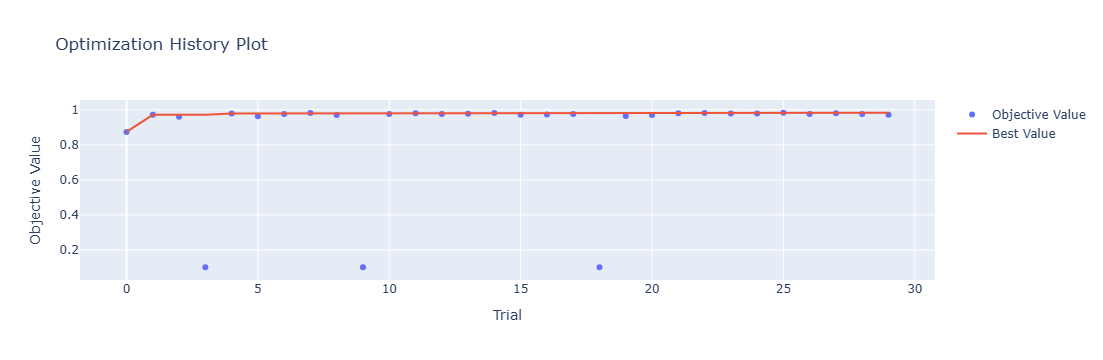

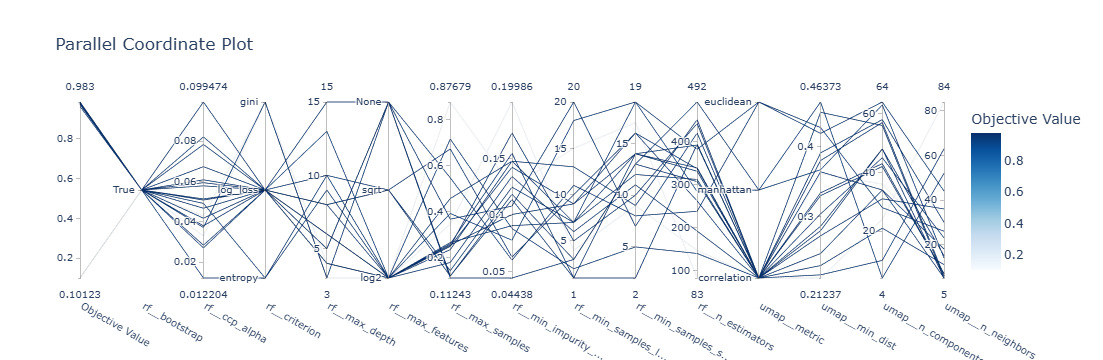

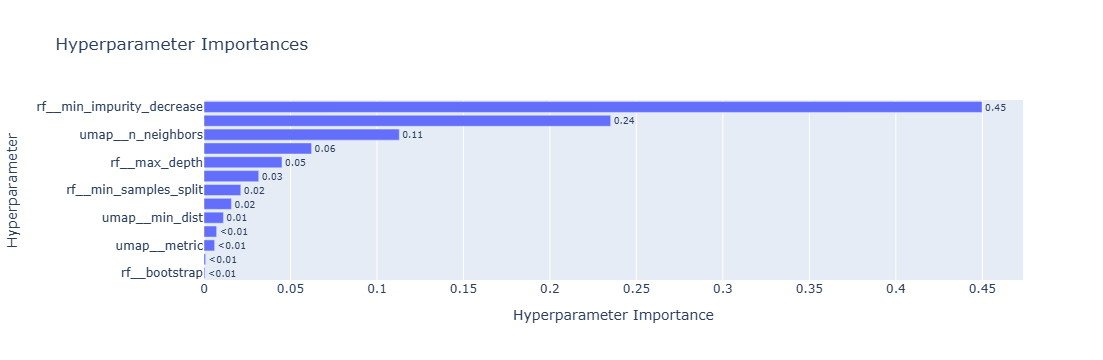

In [140]:
visualize(umap_rf_study)

### XGBoost

In [145]:
def umap_xgb_params(trial):

    return {
        'umap__n_neighbors':trial.suggest_int('umap__n_neighbors',5,100),
        'umap__n_components':trial.suggest_int('umap__n_components',2,64),
        'umap__min_dist':trial.suggest_float('umap__min_dist',0.1,0.5),
        'umap__metric':trial.suggest_categorical('umap__metric',['euclidean', 'manhattan', 'correlation']),
        'xgb__max_depth': trial.suggest_int('xgb__max_depth', 3, 12),
        'xgb__max_leaves': trial.suggest_int('xgb__max_leaves', 8, 256),
        'xgb__min_child_weight': trial.suggest_int('xgb__min_child_weight', 1, 10),
        'xgb__gamma': trial.suggest_float('xgb__gamma', 0.0, 1.0),
        'xgb__subsample': trial.suggest_float('xgb__subsample', 0.6, 1.0),
        'xgb__colsample_bytree': trial.suggest_float('xgb__colsample_bytree', 0.6, 1.0),
        'xgb__colsample_bylevel': trial.suggest_float('xgb__colsample_bylevel', 0.6, 1.0),
        'xgb__colsample_bynode': trial.suggest_float('xgb__colsample_bynode', 0.6, 1.0),
        'xgb__learning_rate': trial.suggest_float('xgb__learning_rate', 0.01, 0.3, log=True),
        'xgb__n_estimators': trial.suggest_int('xgb__n_estimators', 50, 1000),
        'xgb__reg_alpha': trial.suggest_float('xgb__reg_alpha', 0.0, 1.0),
        'xgb__reg_lambda': trial.suggest_float('xgb__reg_lambda', 0.0, 1.0),
        'xgb__max_delta_step': trial.suggest_int('xgb__max_delta_step', 0, 10),
        'xgb__tree_method': 'hist',  # Faster for medium-sized datasets
        'xgb__max_bin':trial.suggest_int('xgb__max_bin', 64, 1024, step=64),
        'xgb__eval_metric': 'mlogloss',
        }

umap_xgb = Pipeline([
    ('umap',umap.UMAP()),
    ('xgb',XGBClassifier())
])

umap_xgb_study, umap_xgb = model_trainer(umap_xgb,umap_xgb_params,X_train,y_train)

[I 2025-04-17 10:59:52,904] A new study created in memory with name: no-name-22fa3eed-7f36-4381-9c5f-bdc1b3b76644
[I 2025-04-17 11:00:46,560] Trial 0 finished with value: 0.9735817677856483 and parameters: {'umap__n_neighbors': 40, 'umap__n_components': 61, 'umap__min_dist': 0.39279757672456206, 'umap__metric': 'euclidean', 'xgb__max_depth': 3, 'xgb__max_leaves': 223, 'xgb__min_child_weight': 7, 'xgb__gamma': 0.7080725777960455, 'xgb__subsample': 0.608233797718321, 'xgb__colsample_bytree': 0.9879639408647978, 'xgb__colsample_bylevel': 0.9329770563201687, 'xgb__colsample_bynode': 0.6849356442713105, 'xgb__learning_rate': 0.01855998084649059, 'xgb__n_estimators': 224, 'xgb__reg_alpha': 0.3042422429595377, 'xgb__reg_lambda': 0.5247564316322378, 'xgb__max_delta_step': 4, 'xgb__max_bin': 320}. Best is trial 0 with value: 0.9735817677856483.
[I 2025-04-17 11:01:40,193] Trial 1 finished with value: 0.9686130787393491 and parameters: {'umap__n_neighbors': 63, 'umap__n_components': 10, 'umap__m

In [146]:
print('Best Trial Value: ',umap_xgb_study.best_trial.value)
print('Train score: ',accuracy_score(y_train,umap_xgb.predict(X_train)))
print('Test score: ',accuracy_score(y_test,umap_xgb.predict(X_test)))

Best Trial Value:  0.982211956335763
Train score:  0.9960763798064347
Test score:  0.9777406789092933


In [147]:
print(classification_report(y_test,umap_xgb.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       178
           1       0.93      0.99      0.96       182
           2       0.99      0.98      0.99       177
           3       0.98      0.97      0.97       183
           4       0.99      0.99      0.99       181
           5       0.98      0.98      0.98       182
           6       0.99      0.99      0.99       181
           7       0.99      0.97      0.98       179
           8       0.97      0.93      0.95       174
           9       0.95      0.97      0.96       180

    accuracy                           0.98      1797
   macro avg       0.98      0.98      0.98      1797
weighted avg       0.98      0.98      0.98      1797



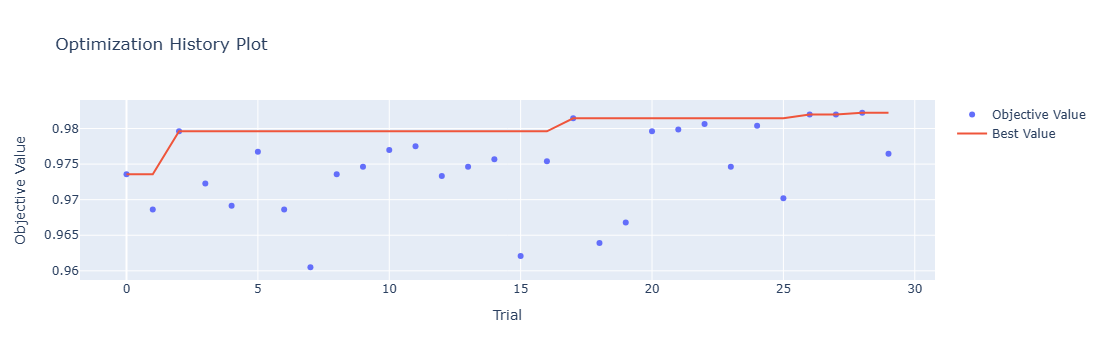

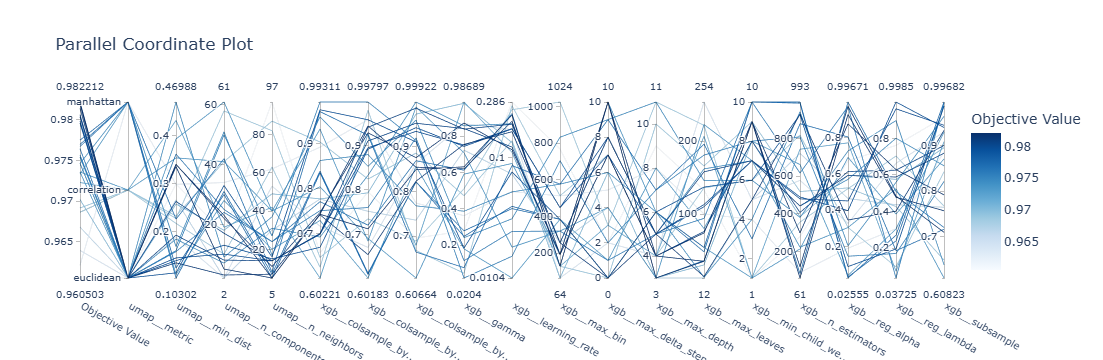

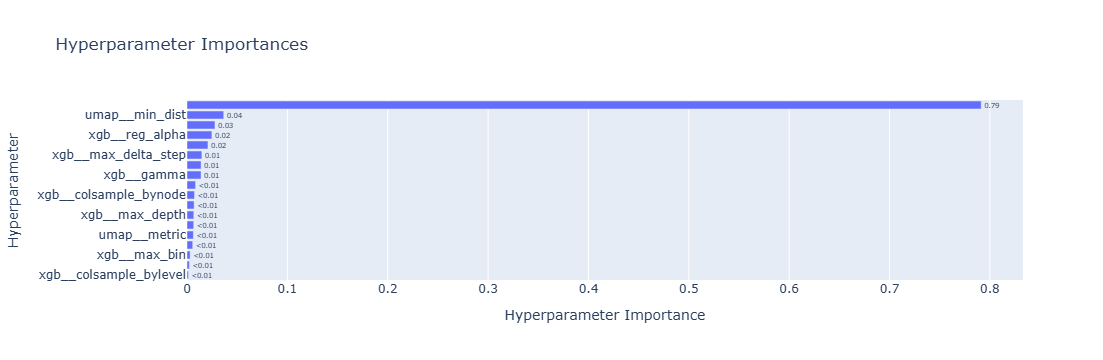

In [148]:
visualize(umap_xgb_study)

### Logistic Regression

In [170]:
def umap_logit_params(trial):
    params = {
        'umap__n_neighbors': trial.suggest_int('umap__n_neighbors', 5, 100),
        'umap__n_components': trial.suggest_int('umap__n_components', 2, 64),
        'umap__min_dist': trial.suggest_float('umap__min_dist', 0.1, 0.5),
        'umap__metric': trial.suggest_categorical('umap__metric', ['euclidean', 'manhattan', 'correlation']),
        'logit__solver': trial.suggest_categorical('logit__solver', ['liblinear', 'saga', 'lbfgs', 'newton-cg', 'sag']),
        'logit__penalty': trial.suggest_categorical('logit__penalty', ['l1', 'l2',None]),
        'logit__C': trial.suggest_float('logit__C', 0.1, 1.0)
    }
    valid_combinations = {
        'liblinear': ['l1', 'l2'],
        'saga': ['l1', 'l2', 'elasticnet', None],
        'lbfgs': ['l2', None],
        'newton-cg': ['l2', None],
        'sag': ['l2', None],
    }
    
    if params['logit__penalty'] not in valid_combinations[params['logit__solver']]:
        raise optuna.TrialPruned()
    
    if params['logit__penalty'] == 'elasticnet':
        params['logit__l1_ratio'] = trial.suggest_float('logit__l1_ratio', 0, 1.0)
    else:
        params['logit__l1_ratio'] = None

    return params

umap_logit = Pipeline([
    ('umap',umap.UMAP()),
    ('logit',LogisticRegression(random_state=seed,n_jobs=-1,max_iter=1000))
])

umap_logit_study, umap_logit = model_trainer(umap_logit,umap_logit_params,X_train,y_train)

[I 2025-04-21 02:10:59,841] A new study created in memory with name: no-name-3b26bc5a-d6b4-4888-85ed-b727bc546355
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

[I 2025-04-21 02:12:48,290] Trial 0 finished with value: 0.9738432056941451 

In [171]:
print('Best Trial Value: ',umap_logit_study.best_trial.value)
print('Train score: ',accuracy_score(y_train,umap_logit.predict(X_train)))
print('Test score: ',accuracy_score(y_test,umap_logit.predict(X_test)))

Best Trial Value:  0.9840440748725319
Train score:  0.9971226785247188
Test score:  0.9827490261547023


In [172]:
print(classification_report(y_test,umap_logit.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       178
           1       0.94      0.99      0.97       182
           2       1.00      0.99      0.99       177
           3       0.98      0.98      0.98       183
           4       0.99      0.99      0.99       181
           5       0.99      0.98      0.99       182
           6       0.99      1.00      1.00       181
           7       0.99      0.98      0.99       179
           8       0.98      0.94      0.96       174
           9       0.97      0.97      0.97       180

    accuracy                           0.98      1797
   macro avg       0.98      0.98      0.98      1797
weighted avg       0.98      0.98      0.98      1797



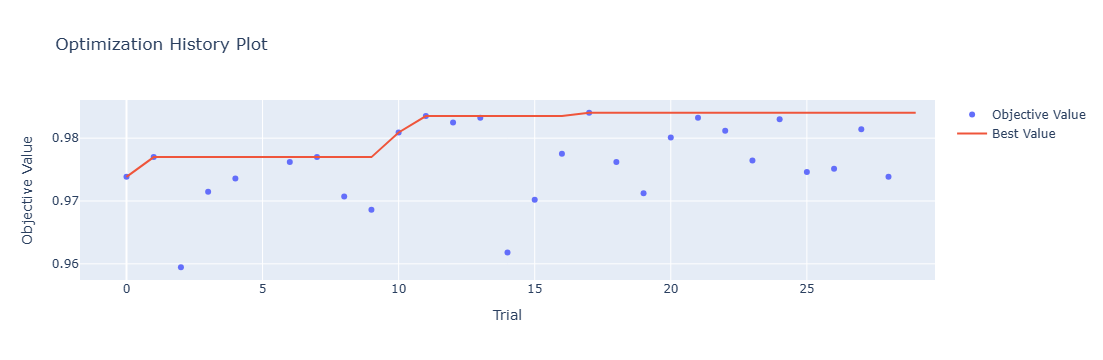

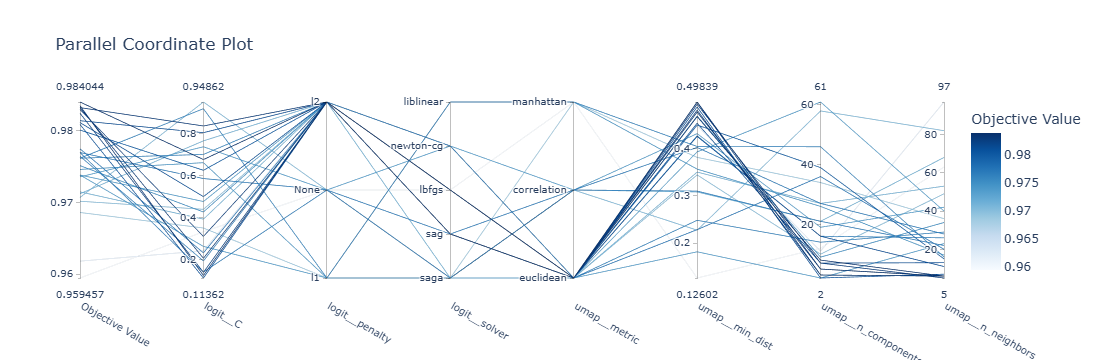

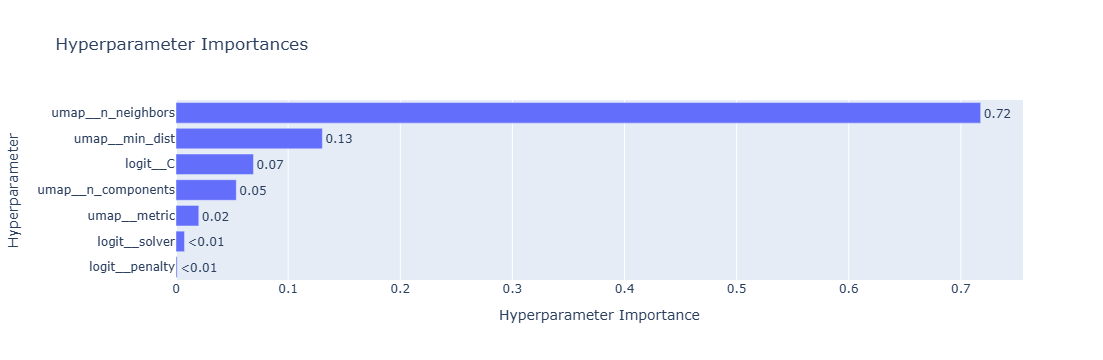

In [173]:
visualize(umap_logit_study)

In [178]:
def umap_knn_params(trial):

    return {
        'umap__n_neighbors':trial.suggest_int('umap__n_neighbors',5,100),
        'umap__n_components':trial.suggest_int('umap__n_components',2,64),
        'umap__min_dist':trial.suggest_float('umap__min_dist',0.1,0.5),
        'umap__metric':trial.suggest_categorical('umap__metric',['euclidean', 'manhattan', 'correlation']),
        'knn__n_neighbors': trial.suggest_int('knn__n_neighbors', 5, 25),
        'knn__algorithm': trial.suggest_categorical('knn__algorithm',['ball_tree','kd_tree']),
        'knn__leaf_size': trial.suggest_int('knn__leaf_size',20,50)
        }

umap_knn = Pipeline([
    ('umap',umap.UMAP()),
    ('knn',KNeighborsClassifier(n_jobs=-1))
])

umap_knn_study, umap_knn = model_trainer(umap_knn,umap_knn_params,X_train,y_train)

[I 2025-04-21 02:46:03,987] A new study created in memory with name: no-name-f1b65d15-c2de-43c5-a255-42fc05133cc1
[I 2025-04-21 02:46:55,573] Trial 0 finished with value: 0.9743664237073537 and parameters: {'umap__n_neighbors': 40, 'umap__n_components': 61, 'umap__min_dist': 0.39279757672456206, 'umap__metric': 'euclidean', 'knn__n_neighbors': 6, 'knn__algorithm': 'ball_tree', 'knn__leaf_size': 41}. Best is trial 0 with value: 0.9743664237073537.
[I 2025-04-21 02:47:37,990] Trial 1 finished with value: 0.9832587345583959 and parameters: {'umap__n_neighbors': 6, 'umap__n_components': 63, 'umap__min_dist': 0.4329770563201687, 'umap__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__algorithm': 'ball_tree', 'knn__leaf_size': 29}. Best is trial 1 with value: 0.9832587345583959.
[I 2025-04-21 02:48:30,711] Trial 2 finished with value: 0.9720124559422374 and parameters: {'umap__n_neighbors': 63, 'umap__n_components': 10, 'umap__min_dist': 0.21685785941408728, 'umap__metric': 'correlation',

In [179]:
print('Best Trial Value: ',umap_knn_study.best_trial.value)
print('Train score: ',accuracy_score(y_train,umap_knn.predict(X_train)))
print('Test score: ',accuracy_score(y_test,umap_knn.predict(X_test)))

Best Trial Value:  0.9837822947678199
Train score:  0.9963379544860057
Test score:  0.9821925431274346


In [180]:
print(classification_report(y_test,umap_knn.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       178
           1       0.93      0.99      0.96       182
           2       1.00      0.99      0.99       177
           3       0.98      0.98      0.98       183
           4       0.99      0.99      0.99       181
           5       0.99      0.98      0.99       182
           6       0.99      1.00      1.00       181
           7       0.99      0.97      0.98       179
           8       0.98      0.94      0.96       174
           9       0.96      0.98      0.97       180

    accuracy                           0.98      1797
   macro avg       0.98      0.98      0.98      1797
weighted avg       0.98      0.98      0.98      1797



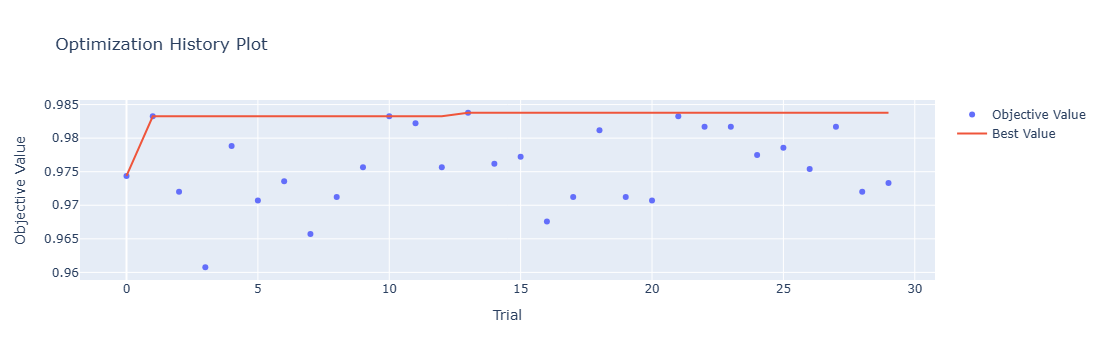

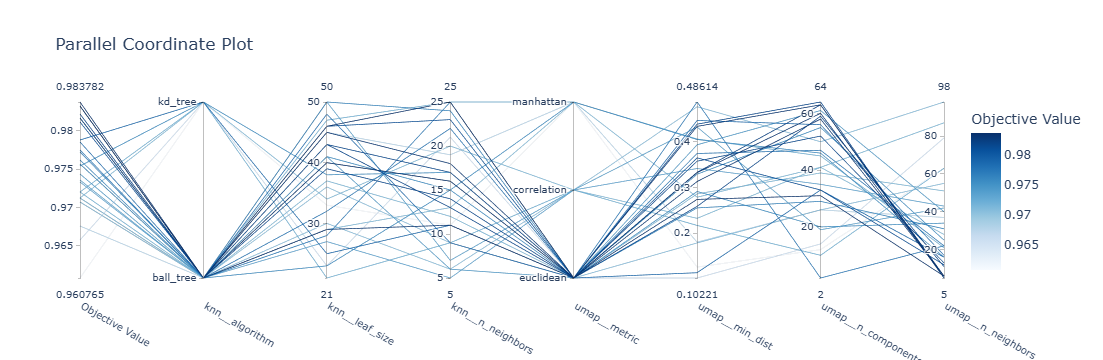

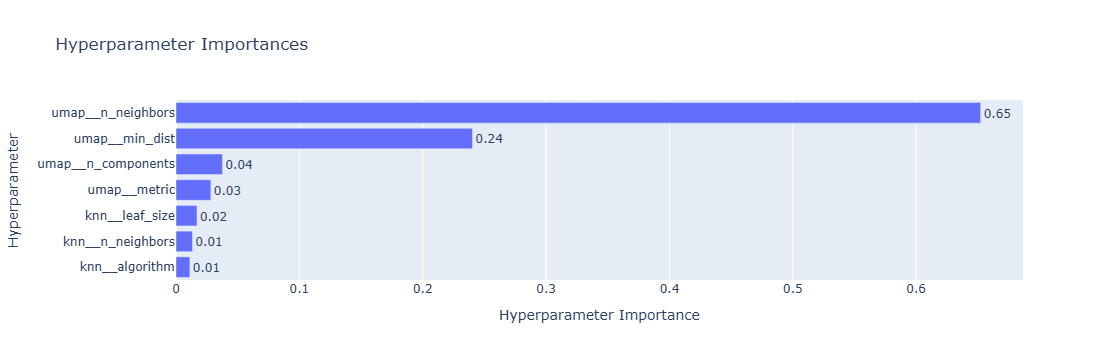

In [182]:
visualize(umap_knn_study)

## Comparison

In [203]:
def score_compare(models,scoring,X,y):

    import pandas as pd
    
    if not isinstance(models,dict):
        raise Exception('Provide the model and model name in a dictionary format')
    if not isinstance(scoring,list):
        scoring = [scoring]


    model_names = list(models.keys())
    score_names = [score.__name__ for score in scoring]
    
    output = pd.DataFrame(index=model_names,columns=score_names)
    
    for m in range(len(models)):
        y_pred = models[model_names[m]].predict(X)
        for s in range(len(scoring)):
            output.loc[model_names[m],score_names[s]] = scoring[s](y,y_pred,average='macro')
    return output
    

In [212]:
models = {
    'Logistic Regression':umap_logit,
    'K-Nearest Neighbor':umap_knn,
    'Random Forest':umap_rf,
    'XG Boost':umap_xgb
         }

In [204]:
scores = score_compare(models,[precision_score, recall_score, f1_score],X_test,y_test)

,precision_score,recall_score,f1_score
Logistic Regression,0.98312,0.982594,0.98272
K-Nearest Neighbor,0.982699,0.982044,0.982196
Random Forest,0.979341,0.978108,0.978395
XG Boost,0.978192,0.97758,0.977712


In [223]:
scores = []
model_names = []
cv = 10
for mod in models:
    score = cross_val_score(models[mod],X_test,y_test,cv=cv,scoring='f1_macro')
    model = [mod]*cv
    scores.extend(score)
    model_names.extend(model)

<Axes: >

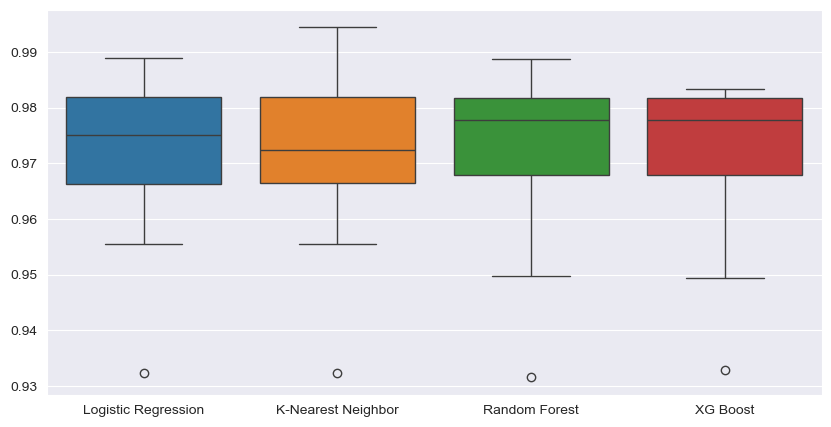

In [224]:
plt.figure(figsize=(10,5))
sns.boxplot(x=model_names,y=scores,hue=model_names)
plt.title('f1 score CV distribution')

Text(0.5, 1.0, 'accuracy score CV distribution')

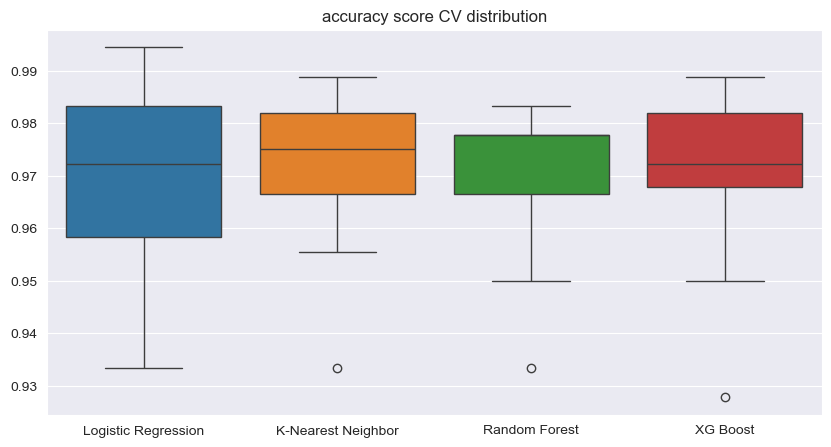

In [225]:
scores = []
model_names = []
cv = 10
for mod in models:
    score = cross_val_score(models[mod],X_test,y_test,cv=cv,scoring='accuracy')
    model = [mod]*cv
    scores.extend(score)
    model_names.extend(model)
plt.figure(figsize=(10,5))
sns.boxplot(x=model_names,y=scores,hue=model_names)
plt.title('accuracy score CV distribution')

Overall Random Forest is better than other algorithms